<a href="https://colab.research.google.com/github/tiwarisubash956/Machine-Learning-Algorithms/blob/main/logistic_regression_using_gradient_descent_for_optimization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [21]:
from sklearn.datasets import make_classification
import numpy  as np
X,y=make_classification(n_samples=1000,n_features=2,n_informative=1,n_redundant=0,random_state=41,class_sep=10,n_classes=2,n_clusters_per_class=1,hypercube=False)
print(X.shape,y.shape)

(1000, 2) (1000,)


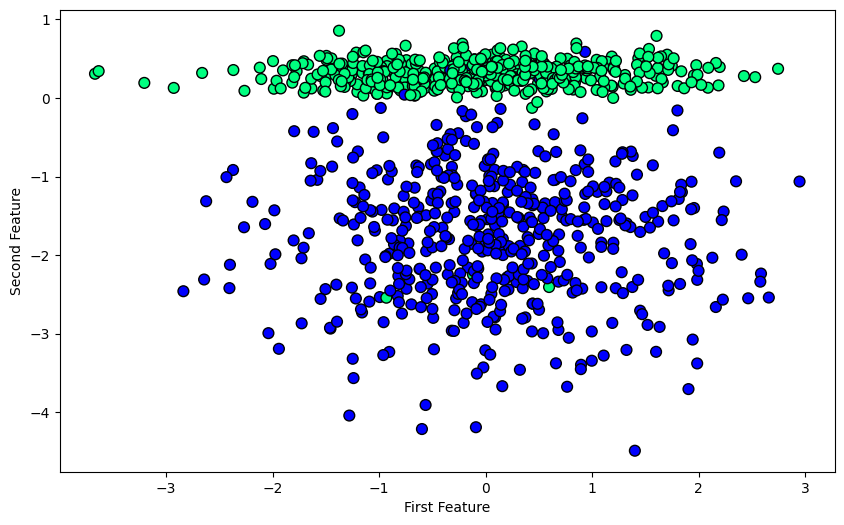

In [22]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',edgecolors='k',s=60)
plt.xlabel('First Feature')
plt.ylabel('Second Feature')
plt.show()


In [27]:
from sklearn.linear_model import LogisticRegression
lor=LogisticRegression(penalty=None,solver='sag')
lor.fit(X,y)
lor.score(X,y)

0.979

In [28]:
print(lor.coef_)
print(lor.intercept_)

[[-0.13691874  5.73837195]]
[1.62220286]


In [29]:
m1=-(lor.coef_[0][0]/lor.coef_[0][1])
b1=-(lor.intercept_[0]/lor.coef_[0][1])

In [30]:
x_input=np.linspace(-3,3,100)
y_input=m1*x_input+b1

In [40]:
def gd(X,y):
  X=np.insert(X,0,1,axis=1)
  weights=np.ones(X.shape[1])
  lr=0.5

  for i in range(2500):
    y_hat=sigmoid(np.dot(X,weights))
    weights=weights + lr*(np.dot((y-y_hat),X)/X.shape[0])
  return weights[1:],weights[0]


In [41]:
def sigmoid(z):
  return 1/(1+np.exp(-z))


In [42]:
coef_,intercept_=gd(X,y)

In [43]:
m=-(coef_[0]/coef_[1])
b=-(intercept_/coef_[1])

In [44]:
x_input1=np.linspace(-3,3,100)
y_input1=m*x_input+b

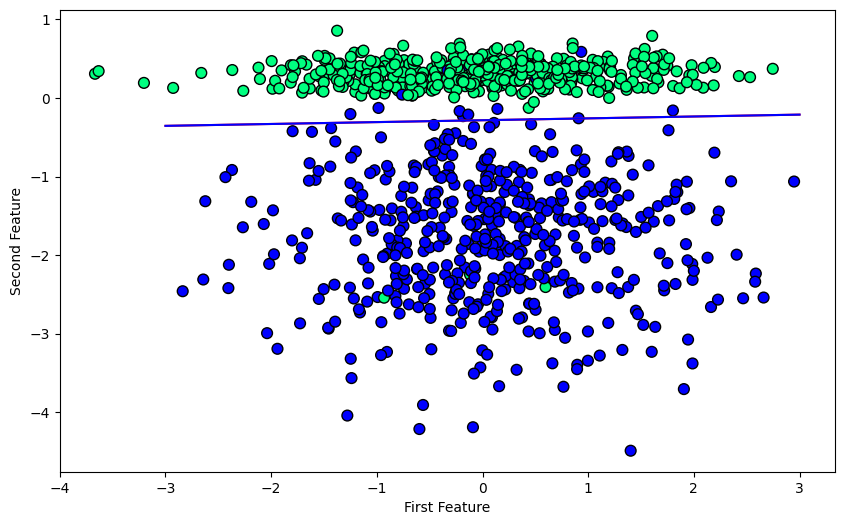

In [46]:
plt.figure(figsize=(10,6))
plt.plot(x_input,y_input,color='r')
plt.plot(x_input1,y_input1,color='b')
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',edgecolors='k',s=60)
plt.xlabel('First Feature')
plt.ylabel('Second Feature')
plt.show()